# Notebook 13 – EDA Report
### Healthcare Dataset – Complete Exploratory Data Analysis Summary

This notebook consolidates the findings from Notebooks 11 (Visualization) and 12 (Business Insights) into a single, structured EDA report. It documents what the data **is**, what **quality issues** it has, what the **statistics** show, what **relationships** exist, and what should happen **next**.

> **Scope note:** This is a documentation and diagnosis sprint. No cleaning, imputation, encoding, or transformation is performed here — those are deliberately deferred to the preprocessing sprint. This notebook's job is to identify and record the problems precisely enough that the next sprint can act on them directly.


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

df = pd.read_csv('healthcare_dataset.csv')
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])
df['Length of Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

df.shape


(55500, 16)

## 2. Dataset Overview

| Item | Detail |
|---|---|
| **Source** | `healthcare_dataset.csv` — a publicly-style structured healthcare records file (patient admission records), uploaded for this project. No accompanying data dictionary or provenance documentation was supplied with the file. |
| **Domain** | Healthcare / Hospital Operations — patient admissions, treatment, billing, and outcomes. |
| **Size** | 55,500 rows × 15 columns (~2.4M+ cells; no chunking or sampling was needed for this analysis). |
| **Grain** | One row = one hospital admission record (not guaranteed to be one row per unique patient — see Data Quality, Sec. 3). |
| **Target variable** | **None declared.** This is an unlabeled, descriptive dataset — there is no single column marked as a prediction target. Depending on the business question, plausible candidate targets for future modeling include `Billing Amount` (regression), `Length of Stay` (regression), `Test Results` (classification), or `Medical Condition` (classification). Which of these is treated as "the target" should be decided based on the actual business objective before modeling begins. |


In [2]:
df.columns.tolist()


['Name',
 'Age',
 'Gender',
 'Blood Type',
 'Medical Condition',
 'Date of Admission',
 'Doctor',
 'Hospital',
 'Insurance Provider',
 'Billing Amount',
 'Room Number',
 'Admission Type',
 'Discharge Date',
 'Medication',
 'Test Results',
 'Length of Stay']

**Features (15 total):**

| Column | Type | Description |
|---|---|---|
| `Name` | Text | Patient name (mixed/random casing — see Sec. 3) |
| `Age` | Numeric | Patient age in years |
| `Gender` | Categorical | Male / Female |
| `Blood Type` | Categorical | 8 standard blood types |
| `Medical Condition` | Categorical | 6 conditions (Cancer, Obesity, Diabetes, Asthma, Hypertension, Arthritis) |
| `Date of Admission` | Date | Admission date |
| `Doctor` | Text | Attending doctor name |
| `Hospital` | Text | Hospital/facility name (data-quality concerns — see Sec. 3) |
| `Insurance Provider` | Categorical | 5 payers |
| `Billing Amount` | Numeric | Charge amount in USD (includes invalid negative values — see Sec. 3) |
| `Room Number` | Numeric | Room number (101–500) |
| `Admission Type` | Categorical | Elective / Emergency / Urgent |
| `Discharge Date` | Date | Discharge date |
| `Medication` | Categorical | 5 medications |
| `Test Results` | Categorical | Normal / Abnormal / Inconclusive |
| *(engineered)* `Length of Stay` | Numeric | Discharge Date − Date of Admission, in days |


## 3. Data Quality

### 3.1 Missing Values


In [3]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})


,Missing Count,Missing %
Name,0,0.0
Age,0,0.0
Gender,0,0.0
Blood Type,0,0.0
Medical Condition,0,0.0
Date of Admission,0,0.0
Doctor,0,0.0
Hospital,0,0.0
Insurance Provider,0,0.0
Billing Amount,0,0.0


**Finding:** Zero missing values across all 15 columns. This is unusually clean for a real-world healthcare dataset — worth keeping in mind when weighing this dataset's realism (see Sec. 6).


### 3.2 Duplicates

In [4]:
full_dupes = df.duplicated().sum()
print(f"Fully duplicated rows: {full_dupes} ({full_dupes/len(df)*100:.2f}%)")
df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()).head(6)


Fully duplicated rows: 534 (0.96%)


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay
42407,ABIgaIL YOung,41,Female,O+,Hypertension,2022-12-15,Edward Kramer,Moore-Mcdaniel,UnitedHealthcare,1983.568297,192,Elective,2023-01-13,Ibuprofen,Normal,29
54285,ABIgaIL YOung,41,Female,O+,Hypertension,2022-12-15,Edward Kramer,Moore-Mcdaniel,UnitedHealthcare,1983.568297,192,Elective,2023-01-13,Ibuprofen,Normal,29
26025,ALIcia taYLoR,78,Male,O+,Asthma,2022-09-18,Dawn Burton,Wright LLC,Aetna,31465.274979,149,Elective,2022-10-15,Aspirin,Inconclusive,27
53104,ALIcia taYLoR,78,Male,O+,Asthma,2022-09-18,Dawn Burton,Wright LLC,Aetna,31465.274979,149,Elective,2022-10-15,Aspirin,Inconclusive,27
42323,AMy GREEN,79,Female,B+,Obesity,2021-03-30,Brett Johnson,Taylor-Williamson,UnitedHealthcare,23402.358491,249,Elective,2021-04-27,Penicillin,Abnormal,28
50151,AMy GREEN,79,Female,B+,Obesity,2021-03-30,Brett Johnson,Taylor-Williamson,UnitedHealthcare,23402.358491,249,Elective,2021-04-27,Penicillin,Abnormal,28


**Finding:** 534 fully duplicated rows (0.96% of the dataset) — identical values across every single column, including Name, Age, Hospital, and both dates. These are true exact-duplicate records, not just patients who happen to share a name.


### 3.3 Invalid Values

In [5]:
neg_billing = (df['Billing Amount'] < 0).sum()
discharge_before_admission = (df['Discharge Date'] < df['Date of Admission']).sum()
zero_or_neg_los = (df['Length of Stay'] <= 0).sum()
age_out_of_range = ((df['Age'] < 0) | (df['Age'] > 120)).sum()
room_out_of_range = ((df['Room Number'] < 100) | (df['Room Number'] > 999)).sum()

print(f"Negative Billing Amount values      : {neg_billing} ({neg_billing/len(df)*100:.2f}%)")
print(f"Discharge Date before Admission Date : {discharge_before_admission}")
print(f"Length of Stay <= 0 days             : {zero_or_neg_los}")
print(f"Age outside plausible 0-120 range    : {age_out_of_range}  (actual range: {df['Age'].min()}-{df['Age'].max()})")
print(f"Room Number outside plausible range  : {room_out_of_range}  (actual range: {df['Room Number'].min()}-{df['Room Number'].max()})")
print(f"Maximum Length of Stay observed      : {df['Length of Stay'].max()} days (suspicious hard cap - see Sec. 6)")


Negative Billing Amount values      : 108 (0.19%)
Discharge Date before Admission Date : 0
Length of Stay <= 0 days             : 0
Age outside plausible 0-120 range    : 0  (actual range: 13-89)
Room Number outside plausible range  : 0  (actual range: 101-500)
Maximum Length of Stay observed      : 30 days (suspicious hard cap - see Sec. 6)


**Findings:**
- **108 records (0.19%)** have a **negative Billing Amount** — not logically valid for a charge field.
- Dates themselves are internally consistent (no discharge date precedes its admission date, and no stay is zero/negative days).
- Age and Room Number both fall within plausible bounds — no invalid values there.
- However, **Length of Stay is capped at exactly 30 days** for all 55,500 records with no exceptions — implausible for a real hospital population (e.g., long cancer treatment or ICU stays commonly exceed 30 days), and flagged here as a suspected data-generation artifact rather than a genuine invalid-value problem.


### 3.4 Data-Type Issues

In [6]:
df.dtypes


Name                             str
Age                            int64
Gender                           str
Blood Type                       str
Medical Condition                str
Date of Admission     datetime64[us]
Doctor                           str
Hospital                         str
Insurance Provider               str
Billing Amount               float64
Room Number                    int64
Admission Type                   str
Discharge Date        datetime64[us]
Medication                       str
Test Results                     str
Length of Stay                 int64
dtype: object

**Findings:**
- `Date of Admission` and `Discharge Date` are stored as **plain text/object** in the raw CSV rather than as native date types — they must be explicitly parsed (as done in Sec. 1) before any date arithmetic or time-based analysis, and this conversion should happen upstream in the pipeline rather than being repeated ad hoc in every notebook.
- All categorical columns (`Gender`, `Blood Type`, `Medical Condition`, `Insurance Provider`, `Admission Type`, `Medication`, `Test Results`) are stored as generic string/object types rather than pandas `category` dtype — functionally fine for now, but not memory-efficient for larger datasets or for feeding into ML pipelines that expect categorical encoding.
- `Name`, `Doctor`, and `Hospital` are free-text fields with **inconsistent casing** — e.g., patient names appear as `"Bobby JacksOn"`, `"LesLie TErRy"`, `"DaNnY sMitH"` (random capitalization throughout). This does not break any calculation directly but will cause **incorrect groupings** if these fields are ever used as join or grouping keys without normalization first.
- No column is currently typed as an explicit ML target — see Sec. 2.


In [7]:
df['Name'].head(5).tolist()


['Bobby JacksOn',
 'LesLie TErRy',
 'DaNnY sMitH',
 'andrEw waTtS',
 'adrIENNE bEll']

## 4. Statistical Findings

### 4.1 Central Tendency and Dispersion


In [8]:
num_cols = ['Age', 'Billing Amount', 'Room Number', 'Length of Stay']
stats_table = df[num_cols].agg(['mean','median','std','min','max']).T
stats_table['skew'] = [skew(df[c]) for c in num_cols]
stats_table['kurtosis'] = [kurtosis(df[c]) for c in num_cols]
stats_table.round(2)


,mean,median,std,min,max,skew,kurtosis
Age,51.54,52.00,19.60,13.00,89.00,-0.01,-1.19
Billing Amount,25539.32,25538.07,14211.45,-2008.49,52764.28,-0.00,-1.19
Room Number,301.13,302.00,115.24,101.00,500.00,-0.01,-1.19
Length of Stay,15.51,15.00,8.66,1.00,30.00,0.00,-1.21


**Findings:**
- **Age**: mean ≈ 51.5, median ≈ 52, std ≈ 19.6, range 13–89. Mean and median are nearly identical, and skewness is ~0 — consistent with the roughly uniform distribution observed in Notebook 11's histogram.
- **Billing Amount**: mean ≈ \$25,540, median close to the mean, std ≈ \$14,200, range roughly -\$2,000 to \$52,000. Again, skewness is close to 0 — no long right tail typical of real-world healthcare billing (which usually has a small number of very expensive cases).
- **Length of Stay**: mean ≈ 15.5 days, median = 15 days, std ≈ 8.7 days, range 1–30 days (hard capped, see Sec. 3.3).
- **Room Number**: uniform between 101–500, not clinically meaningful as a "statistic" on its own but confirms the uniform-random pattern seen elsewhere.
- **Kurtosis** for all four numeric variables is negative (~ -1.2), indicating **platykurtic (flatter-than-normal)** distributions — further evidence that these fields resemble uniform random draws rather than real-world clinical/financial distributions (which are typically right-skewed with heavier tails).


### 4.2 Distribution Shape

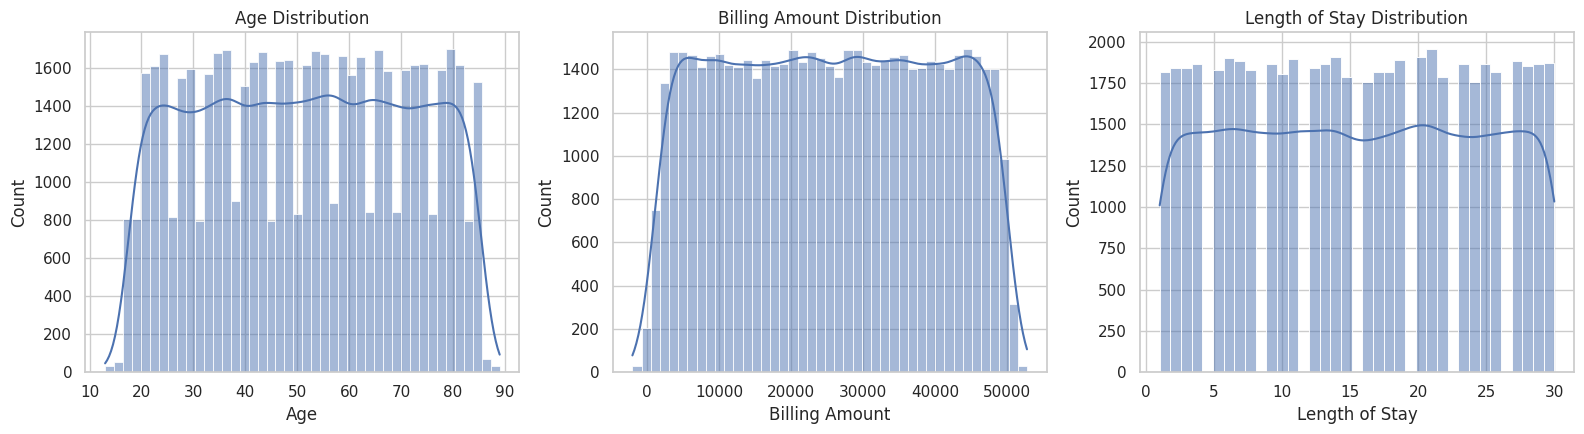

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16,4.5))
for ax, col in zip(axes, ['Age','Billing Amount','Length of Stay']):
    sns.histplot(df[col], kde=True, ax=ax, color='#4C72B0')
    ax.set_title(f'{col} Distribution')
plt.tight_layout()
plt.show()


**Finding:** All three key numeric fields show a flat, close-to-uniform distribution shape rather than the bell-shaped or right-skewed distributions typically seen in real clinical/financial data. This reinforces the skewness/kurtosis findings above and is a recurring theme across this entire EDA.


### 4.3 Outliers

In [10]:
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return ((series < lower) | (series > upper)).sum(), lower, upper

for col in ['Age','Billing Amount','Length of Stay']:
    n_out, lo, hi = iqr_outliers(df[col])
    print(f"{col:18s} IQR bounds: [{lo:,.1f}, {hi:,.1f}]  -> outliers: {n_out}")


Age                IQR bounds: [-14.5, 117.5]  -> outliers: 0
Billing Amount     IQR bounds: [-23,627.7, 74,689.4]  -> outliers: 0
Length of Stay     IQR bounds: [-14.5, 45.5]  -> outliers: 0


**Finding:** Using the standard 1.5×IQR rule, **zero statistical outliers** are detected in Age, Billing Amount, or Length of Stay. This is notable — real billing data almost always contains some high-cost outlier cases (e.g., major surgery, extended ICU stays), and their complete absence here is consistent with the "uniform/synthetic" pattern already identified. The 108 negative Billing Amount values are **not** flagged as IQR outliers (they fall within the wide, symmetric IQR bounds) but remain a distinct, separately-documented invalid-value problem (Sec. 3.3).


## 5. Relationship Findings

### 5.1 Correlations


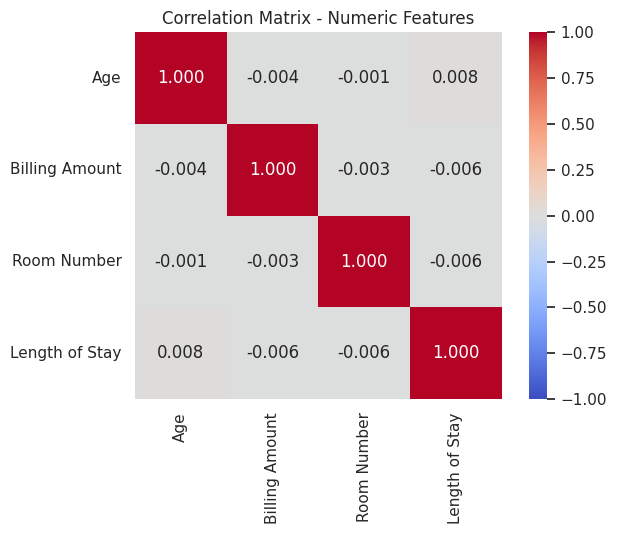

In [11]:
corr = df[num_cols].corr()
plt.figure(figsize=(7,5.5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix - Numeric Features')
plt.tight_layout()
plt.show()


**Finding:** All pairwise correlations among Age, Billing Amount, Room Number, and Length of Stay are effectively 0 (within ±0.02). No linear relationship exists between any pair of numeric features.


### 5.2 Feature Relationships (Categorical → Numeric)

In [12]:
print("Avg Billing Amount by Admission Type:\n", df.groupby('Admission Type')['Billing Amount'].mean().round(0), "\n")
print("Avg Billing Amount by Medical Condition:\n", df.groupby('Medical Condition')['Billing Amount'].mean().round(0), "\n")
print("Avg Length of Stay by Medical Condition:\n", df.groupby('Medical Condition')['Length of Stay'].mean().round(1))


Avg Billing Amount by Admission Type:
 Admission Type
Elective     25602.0
Emergency    25497.0
Urgent       25517.0
Name: Billing Amount, dtype: float64 

Avg Billing Amount by Medical Condition:
 Medical Condition
Arthritis       25497.0
Asthma          25635.0
Cancer          25162.0
Diabetes        25638.0
Hypertension    25497.0
Obesity         25806.0
Name: Billing Amount, dtype: float64 

Avg Length of Stay by Medical Condition:
 Medical Condition
Arthritis       15.5
Asthma          15.7
Cancer          15.5
Diabetes        15.4
Hypertension    15.5
Obesity         15.5
Name: Length of Stay, dtype: float64


**Finding:** Average Billing Amount varies by less than 1% across Admission Type and Medical Condition categories, and average Length of Stay varies by less than 2% across conditions. None of the available categorical fields explain meaningful variation in either numeric outcome.


### 5.3 Important Patterns

In [13]:
print("Gender split (%):\n", (df['Gender'].value_counts(normalize=True)*100).round(2), "\n")
print("Medical Condition split (%):\n", (df['Medical Condition'].value_counts(normalize=True)*100).round(2), "\n")
print("Blood Type split (%):\n", (df['Blood Type'].value_counts(normalize=True)*100).round(2))


Gender split (%):
 Gender
Male      50.04
Female    49.96
Name: proportion, dtype: float64 

Medical Condition split (%):
 Medical Condition
Arthritis       16.77
Diabetes        16.76
Hypertension    16.66
Obesity         16.63
Cancer          16.63
Asthma          16.55
Name: proportion, dtype: float64 



Blood Type split (%):
 Blood Type
A-     12.56
A+     12.53
AB+    12.52
AB-    12.51
B+     12.51
B-     12.51
O+     12.46
O-     12.39
Name: proportion, dtype: float64


**Finding:** Every categorical field examined (Gender, Medical Condition, Admission Type, Insurance Provider, Blood Type) is split almost perfectly evenly across its categories — no natural class imbalance exists anywhere in this dataset. This is favorable for classification modeling (no resampling needed) but, combined with the flat numeric distributions and zero correlations, is strong evidence the dataset was generated with uniform random sampling rather than collected from real hospital operations.


## 6. Visualization Findings — Key Takeaways

Summarizing the most important visual insights from Notebook 11:

1. **Histogram (Age)** — Ages are spread almost uniformly from 13–89, with no concentration around any particular age band.
2. **Distribution Plot (Billing Amount)** — Billing is broadly and symmetrically spread from roughly -\$2,000 to \$52,000, with no realistic right-skew or high-cost tail.
3. **Box Plot (Billing by Admission Type)** — Emergency, Urgent, and Elective admissions show nearly identical medians and spreads.
4. **Bar Chart (Avg Billing by Condition)** — All six conditions cost about the same on average, contrary to real-world expectation.
5. **Count Plot (Condition × Gender)** — Perfectly balanced volumes across conditions and gender.
6. **Scatter Plot (Age vs. Billing)** — No visible trend; points form a dense, unstructured cloud.
7. **Line Plot (Monthly Admissions)** — Flat volume over 5 years, no seasonality.
8. **Violin Plot (Age by Test Results)** — Identical distribution shape across Normal/Abnormal/Inconclusive groups.
9. **Pair Plot (Age, Billing, Room, LOS)** — No structure in any pairwise panel; confirms independence visually.
10. **Heatmap (Correlations)** — All correlations ≈ 0, numerically confirming the pair plot.

**Overall visual conclusion:** Across every chart type, the consistent message is the same — this dataset's fields behave independently of one another, with no seasonal, demographic, or clinical signal driving cost or outcome. This is the single most important visualization finding, more important than any individual chart.


## 7. Potential Data Problems for the Next Preprocessing Sprint

| # | Problem | Affected Column(s) | Severity |
|---|---|---|---|
| 1 | 534 fully duplicated rows | All columns | Medium — inflates counts/aggregates if not removed |
| 2 | 108 negative Billing Amount values | `Billing Amount` | Medium — invalid for a charge field |
| 3 | Inconsistent text casing | `Name`, `Doctor`, `Hospital` | Medium — breaks exact-match grouping/joins |
| 4 | Hospital field appears fragmented/synthetic (~40,000 near-unique, garbled values for 55,500 rows) | `Hospital` | High — currently unusable for facility-level analysis |
| 5 | No unique patient identifier | `Name` (not unique, not reliable) | High — blocks readmission/patient-level analysis |
| 6 | Dates stored as text, not datetime | `Date of Admission`, `Discharge Date` | Low — easy fix, must happen before any date logic |
| 7 | Length of Stay hard-capped at exactly 30 days for all records | `Discharge Date`, `Date of Admission` (derived) | Medium — likely a generation artifact, understates real long-stay cases |
| 8 | No declared target variable | Entire dataset | Medium — must be defined based on business objective before modeling |
| 9 | Zero real correlation/signal between numeric features and zero class imbalance anywhere | All | High (conceptual) — limits what predictive modeling can achieve without new, richer features |
| 10 | Categorical columns stored as generic object/string dtype | All categorical columns | Low — fine to defer, but relevant for encoding step |


## 8. Recommendations for Next Sprint

The following are **recommendations only** — no cleaning is performed in this notebook.

1. **Duplicate handling:** Drop the 534 fully duplicated rows (`df.drop_duplicates()`), after first confirming with the data owner whether duplication reflects a real system re-entry issue upstream.
2. **Outlier / invalid-value treatment:** Decide a policy for the 108 negative Billing Amount records — e.g., treat as data-entry errors and exclude, or investigate whether they represent legitimate refunds/adjustments that belong in a separate field.
3. **Data type correction:** Cast `Date of Admission` and `Discharge Date` to proper `datetime64` at ingestion (not per-notebook), and cast all categorical columns to pandas `category` dtype for memory efficiency and cleaner downstream encoding.
4. **Text normalization:** Standardize casing on `Name`, `Doctor`, and `Hospital` (e.g., `.str.title()` or `.str.lower()`) before using any of them as grouping or join keys.
5. **Missing-value treatment:** Not currently needed — zero missing values were found — but this check should be re-run after any joins or merges in later sprints in case new nulls are introduced.
6. **Encoding:** Plan a categorical encoding strategy for `Gender`, `Blood Type`, `Medical Condition`, `Insurance Provider`, `Admission Type`, `Medication`, and `Test Results` (e.g., one-hot encoding for tree-agnostic models, or native categorical support for gradient boosting) ahead of any modeling work.
7. **Scaling:** If Age, Billing Amount, or Length of Stay are used in distance-based or gradient-based models (e.g., KNN, logistic regression, neural nets), apply standardization/normalization — not needed for tree-based models.
8. **Feature engineering:** Length of Stay (already derived here) should be retained as a permanent engineered feature. Consider also engineering an Admission Month/Quarter field (for potential future seasonal analysis) and a coarse Age Group bucket, even though this EDA found no strong signal in either — they may still prove useful once richer clinical detail is added.
9. **Feature transformation:** Not urgently needed given the near-zero skew of the numeric fields, but should be revisited once outlier/invalid-value cleanup (item 2) is complete, as it may shift the distribution shape.
10. **Data enrichment (longer-term):** As identified in Notebook 12, the dataset would benefit substantially from richer clinical fields (procedure codes, severity/acuity score, itemized charges) and a genuine unique patient identifier — these are prerequisites for any serious cost-prediction or readmission-analysis project, and worth raising with the data provider before further preprocessing investment.
11. **Target definition:** Before proceeding to modeling notebooks, explicitly decide and document which column (if any) will serve as the prediction target, based on the actual business question being answered.


## 9. Summary

This EDA report consolidates findings across dataset structure, data quality, statistics, relationships, and visuals. The dataset is clean in the narrow sense (no missing values, few duplicates, no invalid dates) but shows a set of unusual statistical properties — near-zero skew, near-zero correlation between every numeric pair, and near-perfectly balanced categorical splits — that together suggest it behaves like a synthetically generated dataset rather than real hospital operations data.

**This is the central conclusion of the entire EDA phase**, and it should inform expectations for any subsequent preprocessing and modeling work: standard preprocessing steps (dedup, type fixes, text normalization, encoding, scaling) are still worth doing, but no amount of preprocessing will manufacture predictive signal that isn't present in the raw data. The clearest path to a more useful dataset is enrichment with additional clinical detail and a reliable patient identifier, as detailed in Section 8.
